### part 2 : embeddings 

tokens as point in the embedding vector space 


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
# imported the principal component analysis library 


## 2.1 What's an Embedding?

An embedding converts a token ID into a vector of numbers.
Let's simulate this with random embeddings first, then use real ones.

In [ ]:
# simulatiing a embedding matrix 
vocab_size = 100000
embedding_dim = 768     # 768 is the default for the BERT and gpt-2 models 


In [7]:
# random embeding matrix (in reality this is learned )

embedding_matrix = np.random.rand(vocab_size , embedding_dim)

print(f" -> embedding matrix shape : {embedding_matrix.shape}")
print(f" -> vocalbulary size : {vocab_size}")
print(f" -> embedding_dim : {embedding_dim}")
print(f" -> vocab size * embedding dim : {vocab_size * embedding_dim}")
print("these are the total parameters just for the embeddings ")

print("\n\n")
print(f" -> size of embedding matrix in GB : {(vocab_size * embedding_dim * 4) / (1024**3)}")



 -> embedding matrix shape : (100000, 768)
 -> vocalbulary size : 100000
 -> embedding_dim : 768
 -> vocab size * embedding dim : 76800000
these are the total parameters just for the embeddings 



 -> size of embedding matrix in GB : 0.286102294921875


In [9]:
import tiktoken
tokenizer = tiktoken.get_encoding("cl100k_base")



In [11]:
text = "Harshwardhan is a data scientist and Snehal is Harshwardhan's wife."
tokens = tokenizer.encode(text)


print(f"text : {text}")
print(f"tokens : {tokens}")
print(f"tokens id : {tokens}")

# Look up each token's embedding
for token_id in tokens:
    embedding = embedding_matrix[token_id]
    print(f"Token {token_id} ('{tokenizer.decode([token_id])}')")
    print(f"  → Embedding shape: {embedding.shape}")
    print(f"  → First 10 values: {embedding[:10].round(3)}")
    print()


text : Harshwardhan is a data scientist and Snehal is Harshwardhan's wife.
tokens : [27588, 939, 1637, 10118, 374, 264, 828, 28568, 323, 51113, 12130, 374, 5340, 939, 1637, 10118, 596, 7555, 13]
tokens id : [27588, 939, 1637, 10118, 374, 264, 828, 28568, 323, 51113, 12130, 374, 5340, 939, 1637, 10118, 596, 7555, 13]
Token 27588 ('Har')
  → Embedding shape: (768,)
  → First 10 values: [0.726 0.818 0.827 0.713 0.825 0.551 0.071 0.432 0.878 0.292]

Token 939 ('sh')
  → Embedding shape: (768,)
  → First 10 values: [0.049 0.144 0.363 0.525 0.089 0.515 0.986 0.198 0.83  0.985]

Token 1637 ('ward')
  → Embedding shape: (768,)
  → First 10 values: [0.692 0.955 0.048 0.579 0.803 0.747 0.427 0.677 0.269 0.946]

Token 10118 ('han')
  → Embedding shape: (768,)
  → First 10 values: [0.894 0.886 0.887 0.66  0.966 0.683 0.845 0.4   0.225 0.603]

Token 374 (' is')
  → Embedding shape: (768,)
  → First 10 values: [0.806 0.961 0.804 0.382 0.82  0.023 0.73  0.217 0.874 0.852]

Token 264 (' a')
  → Embedd

## 2.2 Real embedding : word similarity 

let's use pre trained word embedding to see the embedding in action . We will use the genism's Word2vec model for this 
which is classic but illustrative 



In [14]:
import sys
!{sys.executable} -m pip install --upgrade pip 

Looking in indexes: https://pypi.org/simple/
     ---------------------------------------- 1.8/1.8 MB 2.7 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 22.2.2
    Uninstalling pip-22.2.2:
      Successfully uninstalled pip-22.2.2


In [23]:
!pip install gensim 

  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [716 lines of output]
      C:\Users\manas\AppData\Local\Temp\pip-build-env-bbnyelvt\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\manas\AppData\Local\Temp\pip-build-env-bbnyelvt\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\gensim
      copying gensim\downloader.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\interfaces.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\matutils.py -> build\lib.win-amd64-cpython-314\gensim
      copying gensim\nosy.py -> build\lib.win-amd64-cpython-314\gensim
   

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple/
  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build gensim


In [25]:
!{sys.executable} -m pip install gensim

Looking in indexes: https://pypi.org/simple/
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
    --------------------------------------- 0.5/24.4 MB 2.1 MB/s eta 0:00:12
   - -------------------------------------- 1.0/24.4 MB 2.0 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/24.4 MB 1.9 MB/s eta 0:00:13
   -- ------------------------------------- 1.3/24.4 MB 1.9 MB/s eta 0:00:13
   --- ------------------------------------ 1.8/24.4 MB 1.7 MB/s eta 0:00:14
   --- ------------------------------------ 2.4/24.4 MB 1.7 MB/s eta 0:00:13
   ---- ----------------------------------- 2.6/24.4 MB 1.7 MB/s eta 0:00:13
   ---- ----------------------------------- 2.9/24.4 MB 1.7 MB/s eta 0:00:13
   ----- ---------------------------------- 3.1/24.4 MB 1.6 MB/s eta 0:00:13
   ------ --------------------------------- 3.7/24.4 MB 1.7 MB/s eta 0:00:13
   ------ --------------------------------- 3

In [28]:
import gensim.downloader as api


# loading the pre-trained model

print("loading the word vectors from the pre-trained model... (this takes approx 1 minute for loading )")
word_vectors = api.load("glove-wiki-gigaword-100")  # 100-dimensional GloVe vectors trained on Wikipedia and Gigaword
print(f"loaded  vocabulary of size : {len(word_vectors)} words")



loading the word vectors from the pre-trained model... (this takes approx 1 minute for loading )
[==================================================] 100.0% 128.1/128.1MB downloaded
loaded  vocabulary of size : 400000 words


In [29]:
# find the similar words 

word = "king"
similar = word_vectors.most_similar(word)

print(f"words most similar to {word} : \n")
for similar_word , score in similar:
    print(f"{similar_word} : {score:.4f}")

    

words most similar to king : 

prince : 0.7682
queen : 0.7508
son : 0.7021
brother : 0.6986
monarch : 0.6978
throne : 0.6920
kingdom : 0.6811
father : 0.6802
emperor : 0.6713
ii : 0.6676


In [33]:
# find the similar words 

word = "drug"
similar = word_vectors.most_similar(word)

print(f"words most similar to {word} : \n")
for similar_word , score in similar:
    print(f"{similar_word} : {score:.4f}")

    

words most similar to drug : 

drugs : 0.9052
cocaine : 0.7309
trafficking : 0.7234
narcotics : 0.7122
prescription : 0.6876
traffickers : 0.6865
heroin : 0.6764
treatment : 0.6755
marijuana : 0.6670
medication : 0.6574


In [34]:
# find the similar words 

word = "computer"
similar = word_vectors.most_similar(word)

print(f"words most similar to {word} : \n")
for similar_word , score in similar:
    print(f"{similar_word} : {score:.4f}")

    

words most similar to computer : 

computers : 0.8752
software : 0.8373
technology : 0.7642
pc : 0.7366
hardware : 0.7290
internet : 0.7287
desktop : 0.7234
electronic : 0.7222
systems : 0.7198
computing : 0.7142


In [37]:
# find the similar words 

word = "book"
similar = word_vectors.most_similar(word)

print(f"words most similar to {word} : \n")
for similar_word , score in similar:
    print(f"{similar_word} : {score:.4f}")

    

words most similar to book : 

books : 0.8476
novel : 0.8181
published : 0.8024
story : 0.7941
author : 0.7938
wrote : 0.7931
essay : 0.7822
biography : 0.7755
written : 0.7601
fiction : 0.7550


In [38]:
# YOUR TURN: Change this word
my_word = "muhammad"

if my_word in word_vectors:
    similar = word_vectors.most_similar(my_word, topn=10)
    print(f"Words most similar to '{my_word}':\n")
    for w, score in similar:
        print(f"  {w}: {score:.3f}")
else:
    print(f"'{my_word}' not in vocabulary. Try another word.")

Words most similar to 'muhammad':

  mohammed: 0.819
  prophet: 0.740
  ali: 0.705
  mohammad: 0.705
  muhammed: 0.697
  ahmad: 0.646
  imam: 0.632
  ibn: 0.630
  abdul: 0.626
  hamza: 0.617


In [39]:
# YOUR TURN: Change this word
my_word = "krishna"

if my_word in word_vectors:
    similar = word_vectors.most_similar(my_word, topn=10)
    print(f"Words most similar to '{my_word}':\n")
    for w, score in similar:
        print(f"  {w}: {score:.3f}")
else:
    print(f"'{my_word}' not in vocabulary. Try another word.")

Words most similar to 'krishna':

  rama: 0.727
  radha: 0.702
  gopal: 0.672
  devi: 0.648
  advani: 0.645
  shiva: 0.639
  vishnu: 0.637
  ganesh: 0.632
  reddy: 0.631
  hari: 0.629


In [41]:
# YOUR TURN: Change this word
my_word = "tiwari"

if my_word in word_vectors:
    similar = word_vectors.most_similar(my_word, topn=10)
    print(f"Words most similar to '{my_word}':\n")
    for w, score in similar:
        print(f"  {w}: {score:.3f}")
else:
    print(f"'{my_word}' not in vocabulary. Try another word.")

Words most similar to 'tiwari':

  shweta: 0.611
  dutt: 0.578
  tewari: 0.567
  arjun: 0.567
  jha: 0.567
  sitaram: 0.565
  banerjee: 0.563
  kesri: 0.562
  chaturvedi: 0.561
  mishra: 0.553


In [48]:
# YOUR TURN: Change this word
my_word = "hitler"

if my_word in word_vectors:
    similar = word_vectors.most_similar(my_word, topn=10)
    print(f"Words most similar to '{my_word}':\n")
    for w, score in similar:
        print(f"  {w}: {score:.3f}")
else:
    print(f"'{my_word}' not in vocabulary. Try another word.")

Words most similar to 'hitler':

  adolf: 0.853
  stalin: 0.809
  nazi: 0.783
  nazis: 0.772
  mussolini: 0.720
  goebbels: 0.676
  fascist: 0.664
  reich: 0.660
  himmler: 0.645
  göring: 0.622


## 2.3 The Famous Analogy: King - Man + Woman = ?

In [46]:
# vector arithmatic with words 

result = word_vectors.most_similar(
    positive = ['king' , 'women'], 
    negative = ['man'] , 
    topn = 5
)

print("result of the vector arithmatic with words " , end="\n\n")
print("king - man + women")
print("\n\n")
for word , score  in result:
    print(f"{word} : {score:.3f}")

result of the vector arithmatic with words 

king - man + women



queen : 0.581
crown : 0.519
monarch : 0.517
emperor : 0.512
kingdom : 0.510


In [47]:
# Try more analogies

analogies = [
    (["paris", "germany"], ["france"], "paris - france + germany = ?"),
    (["bigger", "cold"], ["big"], "bigger - big + cold = ?"),
]

for positive, negative, description in analogies:
    print(description)
    result = word_vectors.most_similar(positive=positive, negative=negative, topn=3)
    for word, score in result:
        print(f"  {word}: {score:.3f}")
    print()

paris - france + germany = ?
  berlin: 0.885
  frankfurt: 0.799
  vienna: 0.768

bigger - big + cold = ?
  cooler: 0.688
  warmer: 0.685
  colder: 0.675



## let' visualize the embedding vector space 

embedding are high dimentional . Let's project to 2d to visualize 


In [53]:
word_groups = {
    "royalty": ["king", "queen", "prince", "princess", "royal", "throne"],
    "family": ["man", "woman", "boy", "girl", "father", "mother"],
    "animals": ["dog", "cat", "horse", "bird", "fish", "lion"],
    "tech": ["computer", "software", "internet", "digital", "data", "code"],
}

In [54]:
from turtle import color


words = []
embeddings = []
colors = []
color_map = {"royalty":"purple" , 'family':'blue' , 'animals': "green" , 'tech': "red"}


for group , word_list in word_groups.items():
    for word in word_list:
        if word in word_vectors:
            words.append(word)
            embeddings.append(word_vectors[word])
            colors.append(color_map[group])

embeddings = np.array(embeddings)
print(f"Collected {len(words)} words, each with {embeddings.shape[1]} dimensions")


Collected 24 words, each with 100 dimensions


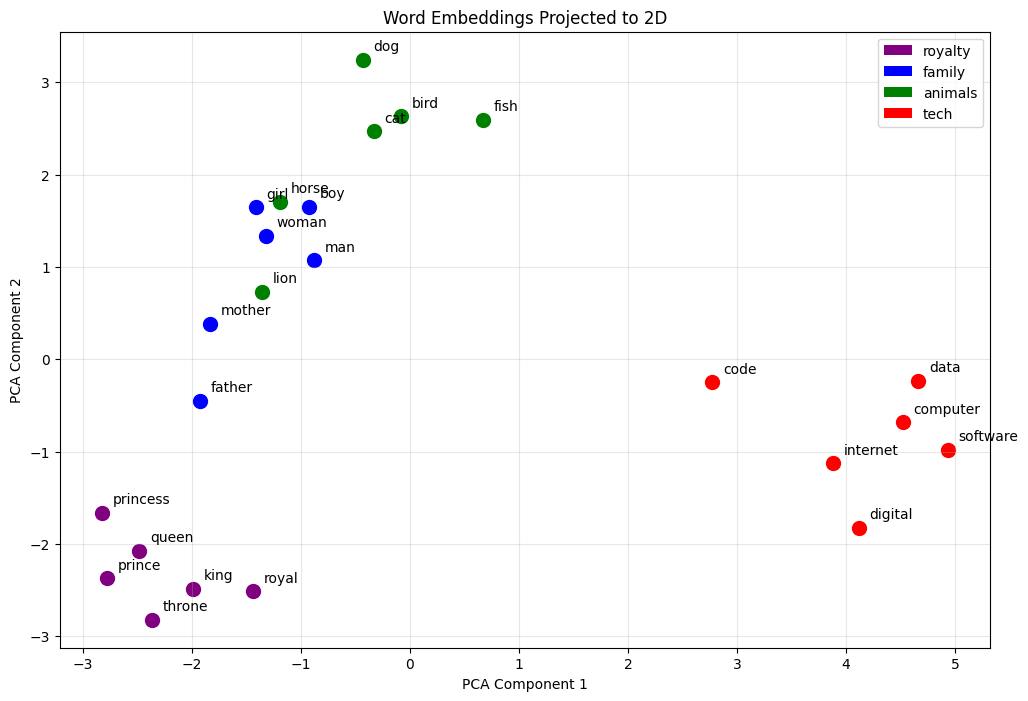

In [55]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(12, 8))
for i, word in enumerate(words):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c=colors[i], s=100)
    plt.annotate(word, (embeddings_2d[i, 0] + 0.1, embeddings_2d[i, 1] + 0.1))

plt.title("Word Embeddings Projected to 2D")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g) for g, c in color_map.items()]
plt.legend(handles=legend_elements)
plt.grid(True, alpha=0.3)
plt.show()